In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import os

OUT_DIR    = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)


In [4]:
df = pd.read_parquet("../outputs/clean_all.parquet")

In [5]:
print(f"Shape      : {df.shape}")
print(f"Route types: {df['route_type'].value_counts().to_dict()}")
print(f"\nTime flags :")
print(f"  is_night        : {df['is_night'].sum():,}")
print(f"  is_peak_evening : {df['is_peak_evening'].sum():,}")
print(f"  is_weekend      : {df['is_weekend'].sum():,}")


Shape      : (142502, 29)
Route types: {'FTL': 98827, 'Carting': 43675}

Time flags :
  is_night        : 62,652
  is_peak_evening : 36,483
  is_weekend      : 37,218


In [6]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor,hour_of_day,day_of_week,is_weekend,is_night,is_peak_evening
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,1.272727,14.0,11.0,11.9653,1.272727,2,3,0,1,0
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,1.200000,10.0,9.0,9.7590,1.111111,2,3,0,1,0
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,1.428571,16.0,7.0,10.8152,2.285714,2,3,0,1,0
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,1.550000,21.0,12.0,13.0224,1.750000,2,3,0,1,0
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,1.545455,6.0,5.0,3.9153,1.200000,2,3,0,1,0


In [8]:
day = (df['is_night'] == 0) & (df['is_peak_evening'] == 0)

- **Node** = a unique hub (`source_center` or `destination_center`)
- **Edge** = a unique corridor pair `(source_center, destination_center)`
- **Edge weight** = median `segment_factor` across all rows for that corridor

In [9]:
all_sources = df['source_center'].nunique()
all_dests   = df['destination_center'].nunique()
all_nodes   = pd.concat([df['source_center'], df['destination_center']]).nunique()
all_corridors = df.groupby(['source_center','destination_center']).ngroups

In [10]:
print(f"Unique source hubs       : {all_sources:,}")
print(f"Unique destination hubs  : {all_dests:,}")
print(f"Unique nodes (combined)  : {all_nodes:,}")
print(f"Unique corridors (edges) : {all_corridors:,}")

Unique source hubs       : 1,508
Unique destination hubs  : 1,481
Unique nodes (combined)  : 1,657
Unique corridors (edges) : 2,783


In [11]:
# Compute edge weights — median segment_factor per corridor
edge_weights = (
    df.groupby(['source_center', 'destination_center'])
    .agg(
        weight = ('segment_factor', 'median'),
        trip_count = ('segment_factor', 'count'),
        mean_factor = ('segment_factor', 'mean'),
        std_factor = ('segment_factor', 'std'),
        source_name = ('source_name',   'first'),
        dest_name = ('destination_name', 'first'),
    )
    .reset_index()
)


In [13]:
print(f"Total corridors           : {len(edge_weights):,}")
print(f"Corridors with 1 trip     : {(edge_weights['trip_count'] == 1).sum():,}")
print(f"Corridors with 5+ trips   : {(edge_weights['trip_count'] >= 5).sum():,}")
print(f"\nEdge weight (median factor) stats:")
print(edge_weights['weight'].describe())

Total corridors           : 2,783
Corridors with 1 trip     : 106
Corridors with 5+ trips   : 2,188

Edge weight (median factor) stats:
count    2783.000000
mean        2.136139
std         1.269743
min         0.414634
25%         1.529412
50%         1.836022
75%         2.281090
max        11.600000
Name: weight, dtype: float64


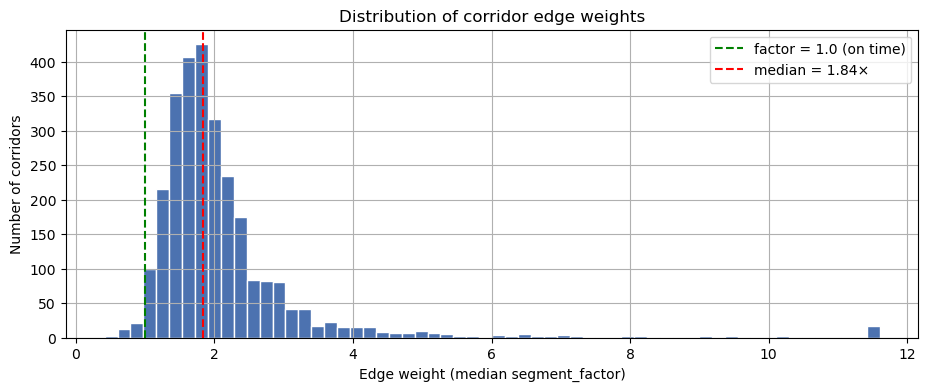

In [17]:
# Distribution of edge weights
fig, ax = plt.subplots(figsize=(11, 4))
edge_weights['weight'].hist(bins=60, ax=ax, color='#4C72B0', edgecolor='white')
ax.axvline(1.0, color='green',  linestyle='--', linewidth=1.5, label='factor = 1.0 (on time)')
ax.axvline(edge_weights['weight'].median(), color='red', linestyle='--', linewidth=1.5,
           label=f"median = {edge_weights['weight'].median():.2f}×")
ax.set_xlabel("Edge weight (median segment_factor)")
ax.set_ylabel("Number of corridors")
ax.set_title("Distribution of corridor edge weights")
ax.legend()
plt.show()


In [22]:
print("Single trip corridors sample:")
print(edge_weights[edge_weights['trip_count'] == 1][
    ['source_name', 'dest_name', 'weight', 'trip_count']
].head(10).to_string(index=False))

Single trip corridors sample:
                 source_name                        dest_name    weight  trip_count
   Delhi_Mayapuri_PC (Delhi)           Delhi_Lajwanti (Delhi)  3.000000           1
         Delhi_Palam (Delhi)          Delhi_Nangli_IP (Delhi)  1.333333           1
    Delhi_Rohini_DPC (Delhi)              North Delhi (Delhi)  2.076923           1
Delhi_Patparganj_DPC (Delhi)           Delhi_Shahdara (Delhi)  3.250000           1
      Delhi_Shahdara (Delhi)     Delhi_Patparganj_DPC (Delhi)  3.222222           1
     Faridabad_Old (Haryana)     FBD_Balabhgarh_DPC (Haryana) 11.600000           1
FBD_Balabhgarh_DPC (Haryana)          Faridabad_Old (Haryana)  2.909091           1
           GGN_DPC (Haryana)          Delhi_Airport_H (Delhi)  3.866667           1
  Sonipat_Kundli_H (Haryana)                     IND250002AAC  5.625000           1
  Sonipat_Kundli_H (Haryana) Baghpat_Barout_D (Uttar Pradesh)  2.954545           1


## build directed graph

In [23]:
def build_graph(edge_df, name="graph"):
    """
    Build a directed weighted graph from an edge dataframe.
    
    Parameters:
        edge_df : DataFrame with columns:
                  source_center, destination_center, weight,
                  trip_count, mean_factor, std_factor,
                  source_name, dest_name
        name    : label for the graph (stored as graph attribute)
    
    Returns:
        G : networkx DiGraph
    """
    G = nx.DiGraph(name=name)

    # Add edges — NetworkX automatically creates nodes
    for _, row in edge_df.iterrows():
        G.add_edge(
            row['source_center'],
            row['destination_center'],
            weight      = row['weight'],
            trip_count  = row['trip_count'],
            mean_factor = row['mean_factor'],
            std_factor  = row['std_factor'] if not pd.isna(row['std_factor']) else 0.0,
            source_name = row['source_name'],
            dest_name   = row['dest_name'],
        )

    return G


In [24]:
# Build main graph using all trips
G_main = build_graph(edge_weights, name="main")

In [25]:
print(f"  Nodes : {G_main.number_of_nodes():,}")
print(f"  Edges : {G_main.number_of_edges():,}")
print(f"  Is directed : {G_main.is_directed()}")

  Nodes : 1,657
  Edges : 2,783
  Is directed : True


In [27]:
sample_edge = list(G_main.edges(data=True))[0]
print(f"  From  : {sample_edge[0]}")
print(f"  To    : {sample_edge[1]}")
print(f"  Attrs : {sample_edge[2]}")

  From  : IND000000AAL
  To    : IND411033AAA
  Attrs : {'weight': 2.25, 'trip_count': 35, 'mean_factor': 3.0696338072574534, 'std_factor': 2.1485000270951464, 'source_name': 'Pune_PC (Maharashtra)', 'dest_name': 'Pune_Tathawde_H (Maharashtra)'}


In [28]:
graphs = {}  # will hold all our graphs

# Main graph
graphs['main'] = G_main

#### stratify by route type

In [29]:
# ── FTL graph ──────────────────────────────────────────────────────────
ftl_edges = (
    df[df['route_type'] == 'FTL']
    .groupby(['source_center', 'destination_center'])
    .agg(
        weight      = ('segment_factor', 'median'),
        trip_count  = ('segment_factor', 'count'),
        mean_factor = ('segment_factor', 'mean'),
        std_factor  = ('segment_factor', 'std'),
        source_name = ('source_name',   'first'),
        dest_name   = ('destination_name', 'first'),
    )
    .reset_index()
)
graphs['ftl'] = build_graph(ftl_edges, name="ftl")

In [30]:
# ── Carting graph ───────────────────────────────────────────────────────
carting_edges = (
    df[df['route_type'] == 'Carting']
    .groupby(['source_center', 'destination_center'])
    .agg(
        weight      = ('segment_factor', 'median'),
        trip_count  = ('segment_factor', 'count'),
        mean_factor = ('segment_factor', 'mean'),
        std_factor  = ('segment_factor', 'std'),
        source_name = ('source_name',   'first'),
        dest_name   = ('destination_name', 'first'),
    )
    .reset_index()
)
graphs['carting'] = build_graph(carting_edges, name="carting")

In [32]:
print(f"  FTL — nodes: {graphs['ftl'].number_of_nodes():,}  edges: {graphs['ftl'].number_of_edges():,}")
print(f"  Carting — nodes: {graphs['carting'].number_of_nodes():,}  edges: {graphs['carting'].number_of_edges():,}")

  FTL — nodes: 1,054  edges: 1,735
  Carting — nodes: 716  edges: 1,071


#### stratify by time of day

In [34]:
time_windows = {
    'night'        : df['is_night'] == 1,
    'peak_evening' : df['is_peak_evening'] == 1,
    'day'          : (df['is_night'] == 0) & (df['is_peak_evening'] == 0),
}

for window_name, mask in time_windows.items():
    subset = df[mask]
    edges = (
        subset.groupby(['source_center', 'destination_center'])
        .agg(
            weight = ('segment_factor', 'median'),
            trip_count = ('segment_factor', 'count'),
            mean_factor = ('segment_factor', 'mean'),
            std_factor = ('segment_factor', 'std'),
            source_name = ('source_name',   'first'),
            dest_name = ('destination_name', 'first'),
        )
        .reset_index()
    )
    graphs[window_name] = build_graph(edges, name=window_name)
    print(f"{window_name} — rows: {mask.sum():,}  nodes: {graphs[window_name].number_of_nodes():,}  edges: {graphs[window_name].number_of_edges():,}")


night — rows: 62,652  nodes: 1,180  edges: 1,769
peak_evening — rows: 36,483  nodes: 782  edges: 1,130
day — rows: 43,367  nodes: 747  edges: 1,064


In [36]:
print("-" * 70)

print(
    f"{'GRAPH':20}"
    f"{'NODES':>10}"
    f"{'EDGES':>10}"
    f"{'SELF_LOOPS':>15}"
    f"{'COMPONENTS':>15}"
)

print("-" * 70)

for name, G in graphs.items():

    n_nodes = G.number_of_nodes()

    n_edges = G.number_of_edges()

    self_loops = nx.number_of_selfloops(G)

    n_components = nx.number_weakly_connected_components(G)

    print(
        f"{name:20}"
        f"{n_nodes:>10}"
        f"{n_edges:>10}"
        f"{self_loops:>15}"
        f"{n_components:>15}"
    )

----------------------------------------------------------------------
GRAPH                    NODES     EDGES     SELF_LOOPS     COMPONENTS
----------------------------------------------------------------------
main                      1657      2783              0             64
ftl                       1054      1735              0             44
carting                    716      1071              0             94
night                     1180      1769              0             85
peak_evening               782      1130              0             60
day                        747      1064              0             61


In [39]:
# Check all edge weights are positive in main graph
weights = [d['weight'] for _, _, d in G_main.edges(data=True)]
print(f"Edge weight min  : {min(weights):.4f}")
print(f"Edge weight max  : {max(weights):.4f}")
print(f"Edge weight mean : {np.mean(weights):.4f}")
print(f"Negative weights : {sum(1 for w in weights if w < 0)}")
print(f"Zero weights     : {sum(1 for w in weights if w == 0)}")


Edge weight min  : 0.4146
Edge weight max  : 11.6000
Edge weight mean : 2.1361
Negative weights : 0
Zero weights     : 0


In [43]:
# Top 20 heaviest corridors (most delayed)
print("Top 20 most delayed corridors (highest median segment_factor):\n")
top_corridors = edge_weights.nlargest(20, 'weight')[
    ['source_name', 'dest_name', 'weight', 'trip_count']
]
top_corridors.columns = ['Source Hub', 'Destination Hub', 'Median Factor', 'Trip Count']
print(top_corridors.to_string(index=False))


Top 20 most delayed corridors (highest median segment_factor):

                           Source Hub                       Destination Hub  Median Factor  Trip Count
              Faridabad_Old (Haryana)          FBD_Balabhgarh_DPC (Haryana)      11.600000           1
              RampuraPhul_DC (Punjab)                 Bhatinda_DPC (Punjab)      11.600000           2
   Kanpur_Central_D_7 (Uttar Pradesh)    Kanpur_Central_H_6 (Uttar Pradesh)      11.600000          33
 Varanasi_Central_H_4 (Uttar Pradesh)     Bhadohi_Rajpura_D (Uttar Pradesh)      11.600000           1
      Sakri_DhuleRoad_D (Maharashtra)        Dhule_MIDCAvdn_I (Maharashtra)      11.600000           2
    Shirpur_KrantiNgr_D (Maharashtra)        Dhule_MIDCAvdn_I (Maharashtra)      11.600000          18
     Shahada_Nandrbar_D (Maharashtra)        Dhule_MIDCAvdn_I (Maharashtra)      11.600000           1
    Nandurbar_DhuleRd_D (Maharashtra)        Dhule_MIDCAvdn_I (Maharashtra)      11.600000           1
         

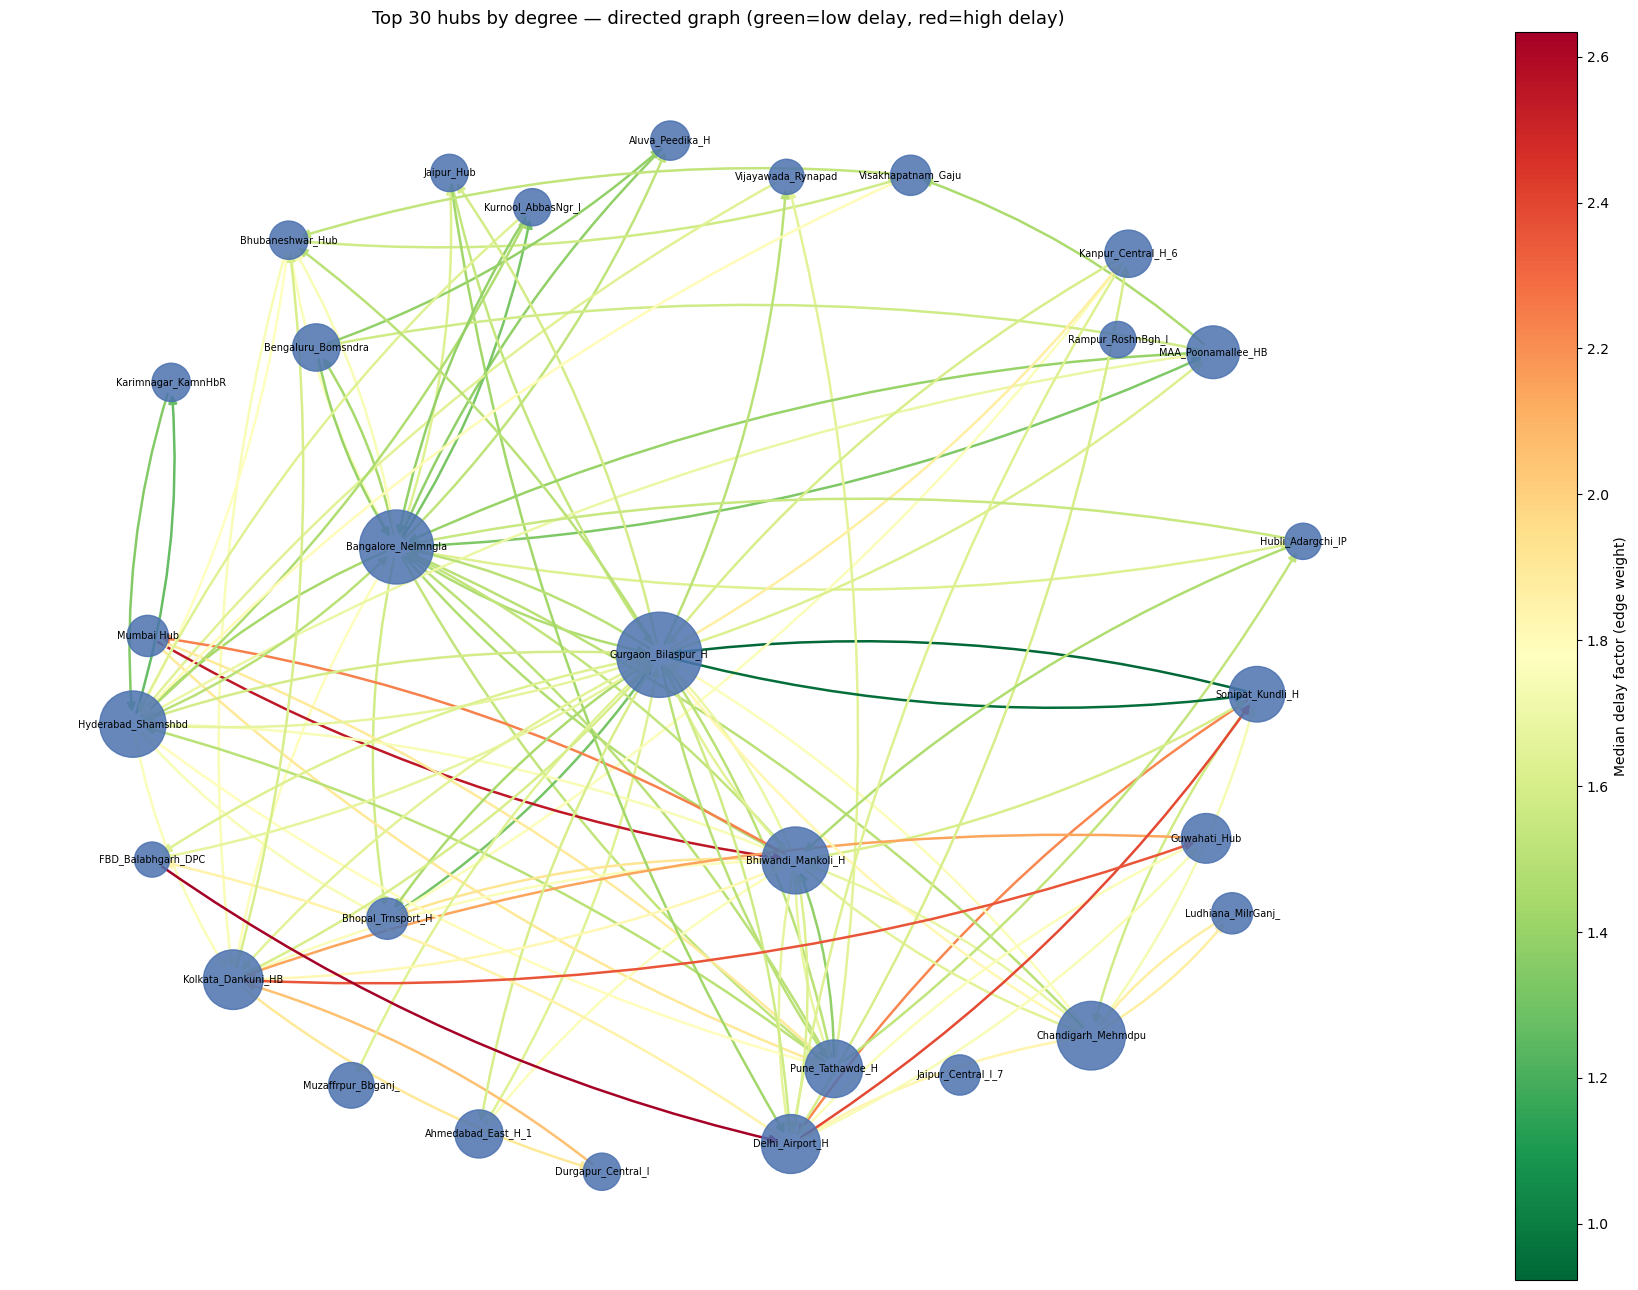

In [48]:
# Build a code → name lookup from edge_weights
name_lookup = {}
for _, row in edge_weights.iterrows():
    name_lookup[row['source_center']]      = row['source_name']
    name_lookup[row['destination_center']] = row['dest_name']

# Top 30 hubs by degree
top_hubs    = sorted(G_main.degree(), key=lambda x: x[1], reverse=True)[:30]
top_hub_ids = [h[0] for h in top_hubs]
subgraph    = G_main.subgraph(top_hub_ids)

fig, ax = plt.subplots(figsize=(18, 13))
pos = nx.spring_layout(subgraph, seed=42, k=2.5)

edge_weights_list = [subgraph[u][v]['weight'] for u, v in subgraph.edges()]

# Node size proportional to degree
node_sizes = [G_main.degree(n) * 40 for n in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos,
    node_size=node_sizes,
    node_color='#4C72B0', alpha=0.85, ax=ax)

# Clean short labels
labels = {n: name_lookup.get(n, n).split('(')[0].strip()[:18] for n in subgraph.nodes()}
nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=7, ax=ax)

nx.draw_networkx_edges(subgraph, pos,
    edge_color=edge_weights_list,
    edge_cmap=plt.cm.RdYlGn_r,
    width=1.8, arrows=True, arrowsize=12,
    connectionstyle='arc3,rad=0.1', ax=ax)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r,
     norm=plt.Normalize(vmin=min(edge_weights_list), vmax=max(edge_weights_list)))
plt.colorbar(sm, ax=ax, label='Median delay factor (edge weight)')
ax.set_title("Top 30 hubs by degree — directed graph (green=low delay, red=high delay)",
             fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

In [49]:
GRAPH_PATH = f"{OUT_DIR}/graphs.pkl"

with open(GRAPH_PATH, 'wb') as f:
    pickle.dump(graphs, f)